To make this model work, we need to do the following: 
* For all crashes in our study area (Oakland + Berkeley), we need to mark whether a crash is associated with a traffic island and signal
* We need to determine which other explanatory variables to include in the model:
    * Traffic signal presence (OSM)
    * Traffic refuge island presence (OSM)
    * Number of lanes (TBD)
        * Looks like you have to play with the overpass API to get this data from OSM https://stackoverflow.com/questions/56558717/query-all-roads-with-overpass-api-and-export-as-polygon
    * Ped characteristics (gender, age, etc.) (retrieve from SWITRS)
        * **How do we do this if ped characteristics are tied to crash party but we want to look at crashes overall?**
    * AADT (From replica)
    * Functional classification of road as a proxy for speed
    * Day of the week (SWITRS)
    * Lighting at intersection (TBD, possibly on OSM)

In [137]:
import pandas as pd
import numpy as np
from statsmodels.miscmodels.ordinal_model import OrderedModel
# from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
import contextily as cx

# Load and clean data

In [138]:
# Load dataset
file_path = "crash_data_for_model.csv"  # Update with the actual file path
df = pd.read_csv(file_path, dtype=str)

In [139]:
# Remove irrelevant columns

df = df[[
        'COLLISION_SEVERITY',
        'AT_FAULT', # No should be reference
        'PARTY_SEX', # Male should be reference
        'PARTY_AGE',
        'RACE', # White should be reference
        'LIGHTING', # Daylight should be reference
        'DAY_OF_WEEK',
        'WEATHER_1', # Clear should be reference
        'PRIMARY_COLL_FACTOR', # Make dummy for A - Vehicle Code Violation
        'PCF_VIOL_CATEGORY',
        'PED_ACTION', # B - Crossing in Crosswalk at Intersection should be reference
        'PARTY_NUMBER_KILLED',
        'PARTY_NUMBER_INJURED',
        'road_class',
        'road_class_name',
        'island_id', # Convert to 1/0
        'volume', 
        'signal_id', # Convert to 1/0
        'POINT_X',
        'POINT_Y'
]]

## Check for blanks or missing information

In [140]:
df.columns

Index(['COLLISION_SEVERITY', 'AT_FAULT', 'PARTY_SEX', 'PARTY_AGE', 'RACE',
       'LIGHTING', 'DAY_OF_WEEK', 'WEATHER_1', 'PRIMARY_COLL_FACTOR',
       'PCF_VIOL_CATEGORY', 'PED_ACTION', 'PARTY_NUMBER_KILLED',
       'PARTY_NUMBER_INJURED', 'road_class', 'road_class_name', 'island_id',
       'volume', 'signal_id', 'POINT_X', 'POINT_Y'],
      dtype='object')

In [141]:
# for col in df.columns: 
#     print(df[col].value_counts(dropna=False))

## Recode variables and create dummy variables

In [142]:
def remap_severity(severity_series):
    # Convert severity values to numeric, coercing errors to NaN
    severity_numeric = pd.to_numeric(severity_series, errors="coerce")
    # Define the mapping from original to reversed scale
    severity_mapping = {1: 4, 2: 3, 3: 2, 4: 1}
    remapped = severity_numeric.map(severity_mapping)
    # Define the order for the categorical variable
    severity_order = [1, 2, 3, 4]
    return pd.Categorical(remapped, categories=severity_order, ordered=True)

# Apply severity remapping using the dedicated function
df["COLLISION_SEVERITY"] = remap_severity(df["COLLISION_SEVERITY"])

In [143]:
# Recode day of the week category
print(df['DAY_OF_WEEK'].value_counts())
df['weekend'] = df["DAY_OF_WEEK"].apply(lambda x: "0" if x in ["1", "2", "3", "4"] else "1")
    # Include Friday because it often features in weekend crashes
df = df.drop('DAY_OF_WEEK', axis=1)
df['weekend'].value_counts()

DAY_OF_WEEK
5    123
3    110
1    102
4     94
2     93
6     82
7     66
Name: count, dtype: int64


weekend
0    399
1    271
Name: count, dtype: int64

In [144]:
# Recode at fault category
fault_dict = {'N':0, 'Y':1}
df['AT_FAULT'] = df['AT_FAULT'].map(fault_dict)
df['AT_FAULT'].value_counts()

AT_FAULT
0    610
1     60
Name: count, dtype: int64

In [145]:
# Recode island data
print(df['island_id'].value_counts().sum())
df['island_id'] = df['island_id'].notna()#.astype(int)
df['island_id'] = df['island_id'].map(int)
print(df['island_id'].value_counts())


36
island_id
0    634
1     36
Name: count, dtype: int64


In [146]:
# Recode signal data
print(df['signal_id'].value_counts().sum())
df['signal_id'] = df['signal_id'].notna()#.astype(int)
df['signal_id'] = df['signal_id'].map(int)
print(df['signal_id'].value_counts())

169
signal_id
0    501
1    169
Name: count, dtype: int64


In [147]:
# Recode ped_action data
print(df['PED_ACTION'].value_counts())
df.loc[df['PED_ACTION']!='B', 'ped_in_xwalk'] = 0
df.loc[df['PED_ACTION']=='B', 'ped_in_xwalk'] = 1 # B - Crossing in Crosswalk at Intersection
df = df.drop('PED_ACTION', axis=1)
df['ped_in_xwalk'].value_counts()

PED_ACTION
B    511
E     53
F     37
D     35
C     27
-      6
G      1
Name: count, dtype: int64


ped_in_xwalk
1.0    511
0.0    159
Name: count, dtype: int64

In [148]:
# Recode primary collision factor data
# print(df['PRIMARY_COLL_FACTOR'].value_counts())
# df.loc[df['PRIMARY_COLL_FACTOR']!='A', 'PRIMARY_COLL_FACTOR'] = 0
# df.loc[df['PRIMARY_COLL_FACTOR']=='A', 'PRIMARY_COLL_FACTOR'] = 1 # A - (Vehicle) Code Violation
# df['PRIMARY_COLL_FACTOR'].value_counts()

In [149]:
# Recode primary collision factor data
print(df['PCF_VIOL_CATEGORY'].value_counts())
df.loc[(df['PCF_VIOL_CATEGORY']!='09')|(df['PCF_VIOL_CATEGORY']!='11'), 'ped_violation_or_auto_row'] = 0
df.loc[(df['PCF_VIOL_CATEGORY']=='09')|(df['PCF_VIOL_CATEGORY']=='11'), 'ped_violation_or_auto_row'] = 1 
    # 09 - Automobile Right of Way
    # 10 - Pedestrian Right of Way
    # 11 - Pedestrian Violation 
    # 12 - Traffic Signals and Signs 
        # Maybe interact this with signal variable
    # 23 - Pedestrian or "Other" Under the Influence of Alcohol or Drug

df = df.drop('PCF_VIOL_CATEGORY', axis=1)
df['ped_violation_or_auto_row'].value_counts()

PCF_VIOL_CATEGORY
10    442
11     62
08     46
00     29
12     28
03     22
21     15
17      6
09      5
01      5
-       3
05      2
22      2
18      2
07      1
Name: count, dtype: int64


ped_violation_or_auto_row
0.0    603
1.0     67
Name: count, dtype: int64

In [150]:
# Recode weather data
print(df['WEATHER_1'].value_counts())
df.loc[df['WEATHER_1']!='A', 'WEATHER_1'] = 0
df.loc[df['WEATHER_1']=='A', 'WEATHER_1'] = 1 # A - Clear
df['WEATHER_1'].value_counts()

WEATHER_1
A    558
B     56
C     41
-     13
F      1
E      1
Name: count, dtype: int64


WEATHER_1
1    558
0    112
Name: count, dtype: int64

In [151]:
# Recode lighting data
print(df['LIGHTING'].value_counts())

# df.loc[df['LIGHTING']!='A', 'LIGHTING'] = 0
# df.loc[df['LIGHTING']=='A', 'LIGHTING'] = 1 # A - Daylight
# df['LIGHTING'].value_counts()

fault_dict = {
    'A': 'daylight',
    'C': 'streetlight', 
    'B': 'dusk_dawn',
    'D': 'no_streetlight',
    'E': 'no_streetlight',
    '-': '-'
}
df['LIGHTING'] = df['LIGHTING'].map(fault_dict)
df['LIGHTING'] = df['LIGHTING'].mask(df['LIGHTING']=='-', np.nan)
df['LIGHTING'].value_counts(dropna=False)

LIGHTING
A    421
C    195
B     30
D     12
E      6
-      6
Name: count, dtype: int64


LIGHTING
daylight          421
streetlight       195
dusk_dawn          30
no_streetlight     18
NaN                 6
Name: count, dtype: int64

In [152]:
# Recode road class
print(df['road_class_name'].value_counts(dropna=False))

# Remove rows with 1 and 2 because these are highways/freeways
df.drop(df[df['road_class_name'] == 'interstate'].index, inplace=True)
df.drop(df[df['road_class_name'] == 'other fwy or expwy'].index, inplace=True)
print(df['road_class_name'].value_counts(dropna=False))

# Create dummy for minor arterial vs. other principal arterial
df.loc[(df['road_class_name']=='minor arterial'), 'road_class'] = 0 
df.loc[(df['road_class_name']=='other principal arterial'), 'road_class'] = 1 
# we may drop these ones:
df.loc[(df['road_class_name']=='major collector')|(df['road_class_name']=='local'), 'road_class'] = 2 

print(df['road_class'].value_counts(dropna=False))


road_class_name
minor arterial              215
other principal arterial    192
local                       189
major collector              66
interstate                    7
other fwy or expwy            1
Name: count, dtype: int64
road_class_name
minor arterial              215
other principal arterial    192
local                       189
major collector              66
Name: count, dtype: int64
road_class
2    255
0    215
1    192
Name: count, dtype: int64


In [153]:
# Recode party_sex
print(df['PARTY_SEX'].value_counts())

# Convert blanks and the one X value to NaN
# pd.crosstab(df['PARTY_SEX'], df['island_id'])
df.drop(df[df['PARTY_SEX']=='-'].index, inplace=True)
df.drop(df[df['PARTY_SEX']=='X'].index, inplace=True)

# df['PARTY_SEX'] = df['PARTY_SEX'].mask((df['PARTY_SEX']=='-')|(df['PARTY_SEX']=='X'), np.nan)

# Mark male as 0, female as 1
df.loc[(df['PARTY_SEX']=='M'), 'PARTY_SEX'] = 0 
df.loc[(df['PARTY_SEX']=='F'), 'PARTY_SEX'] = 1 
df['PARTY_SEX'].value_counts()

PARTY_SEX
M    337
F    316
-      8
X      1
Name: count, dtype: int64


PARTY_SEX
0    337
1    316
Name: count, dtype: int64

In [154]:
# Apply dummy encoding
df = pd.get_dummies(df, columns=[
    # 'PARTY_SEX', # Male should be reference
    'RACE', # White should be reference
    'LIGHTING'
    ], drop_first=True)

display(df)

,COLLISION_SEVERITY,AT_FAULT,PARTY_SEX,PARTY_AGE,WEATHER_1,PRIMARY_COLL_FACTOR,PARTY_NUMBER_KILLED,PARTY_NUMBER_INJURED,road_class,road_class_name,...,weekend,ped_in_xwalk,ped_violation_or_auto_row,RACE_B,RACE_H,RACE_O,RACE_W,LIGHTING_dusk_dawn,LIGHTING_no_streetlight,LIGHTING_streetlight
0,1,0,0,60,0,A,0,1,0,minor arterial,...,0,1.0,0.0,False,False,False,True,False,False,False
1,1,0,0,57,1,A,0,1,2,major collector,...,0,1.0,0.0,True,False,False,False,False,False,False
2,2,0,1,30,1,A,0,1,2,major collector,...,1,1.0,0.0,False,True,False,False,False,False,True
3,2,1,1,13,1,A,0,1,2,major collector,...,1,1.0,1.0,False,True,False,False,False,False,False
4,1,0,1,23,1,A,0,1,2,local,...,0,0.0,0.0,True,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
665,2,0,1,45,1,A,0,1,0,minor arterial,...,0,1.0,0.0,False,False,False,True,False,False,False
666,3,0,1,77,1,A,0,1,2,major collector,...,0,1.0,0.0,False,False,False,True,False,False,False
667,2,0,1,42,1,A,0,1,0,minor arterial,...,1,1.0,0.0,False,False,False,True,False,False,False
668,1,0,0,38,0,A,0,1,0,minor arterial,...,0,1.0,0.0,False,False,False,True,False,False,True


# Reduce sample based on road classification

In [155]:
df['road_class_name'].value_counts()

road_class_name
minor arterial              212
other principal arterial    190
local                       186
major collector              65
Name: count, dtype: int64

In [156]:
pd.crosstab(df['road_class_name'], df['island_id'])

island_id,0,1
road_class_name,,
local,183,3
major collector,65,0
minor arterial,199,13
other principal arterial,170,20


In [157]:
pd.crosstab(df['road_class_name'], df['signal_id'])

signal_id,0,1
road_class_name,,
local,163,23
major collector,52,13
minor arterial,156,56
other principal arterial,117,73


In [158]:
# We could drop local roads, but then we'd lose three crashes
# Instead, let's just drop major collector and see what happens
df.drop(df[df['road_class_name'] == 'major collector'].index, inplace=True)

# Okay so that didn't seem to change much, so let's try dropping local roads too
df.drop(df[df['road_class_name'] == 'local'].index, inplace=True)

df.shape

# Woah okay when we remove local roads, the psuedo R^2 value increase by more than 0.01 and the log likelihood increase by 200 (-600 to -400)

(402, 25)

In [159]:
df['road_class'].value_counts()
# 1 - other principal arterial
# 2 - minor arterial

road_class
0    212
1    190
Name: count, dtype: int64

# Map of final selected variables

In [173]:
df.columns

Index(['COLLISION_SEVERITY', 'AT_FAULT', 'PARTY_SEX', 'PARTY_AGE', 'WEATHER_1',
       'PRIMARY_COLL_FACTOR', 'PARTY_NUMBER_KILLED', 'PARTY_NUMBER_INJURED',
       'road_class', 'road_class_name', 'island_id', 'volume', 'signal_id',
       'POINT_X', 'POINT_Y', 'weekend', 'ped_in_xwalk',
       'ped_violation_or_auto_row', 'RACE_B', 'RACE_H', 'RACE_O', 'RACE_W',
       'LIGHTING_dusk_dawn', 'LIGHTING_no_streetlight',
       'LIGHTING_streetlight'],
      dtype='object')

In [175]:
df['island_id'].value_counts()

island_id
0    369
1     33
Name: count, dtype: int64

In [161]:
df.columns

Index(['COLLISION_SEVERITY', 'AT_FAULT', 'PARTY_SEX', 'PARTY_AGE', 'WEATHER_1',
       'PRIMARY_COLL_FACTOR', 'PARTY_NUMBER_KILLED', 'PARTY_NUMBER_INJURED',
       'road_class', 'road_class_name', 'island_id', 'volume', 'signal_id',
       'POINT_X', 'POINT_Y', 'weekend', 'ped_in_xwalk',
       'ped_violation_or_auto_row', 'RACE_B', 'RACE_H', 'RACE_O', 'RACE_W',
       'LIGHTING_dusk_dawn', 'LIGHTING_no_streetlight',
       'LIGHTING_streetlight'],
      dtype='object')

In [169]:
gdf = gpd.GeoDataFrame(
    df, 
    geometry=gpd.points_from_xy(df.POINT_X, df.POINT_Y),
    crs=4326)

if gdf.crs != 3857:
    gdf = gdf.to_crs(3857)

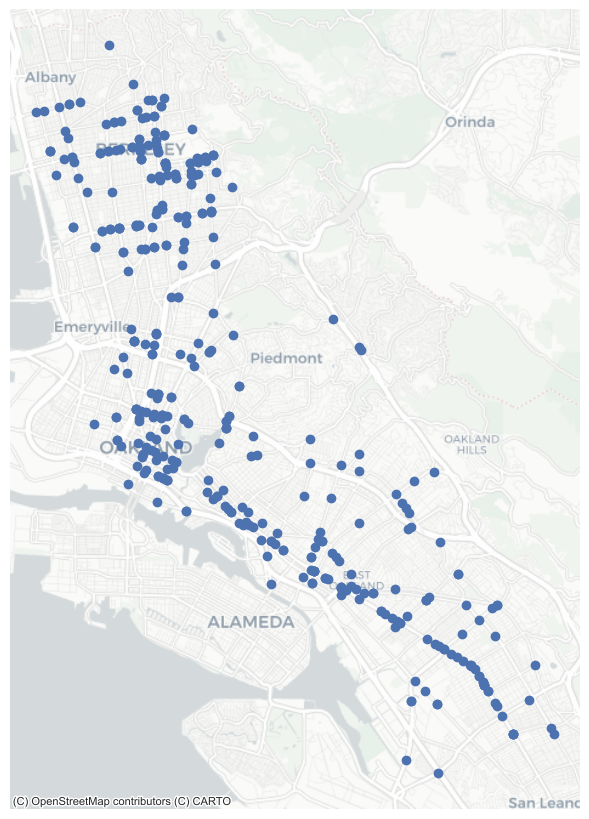

In [ ]:
from matplotlib.patches import Patch

fig = plt.figure(figsize=[12,8])
ax = fig.add_axes([0, 0, 1, 1])

# Create color column based on island_id and signal_ID
colors = []
for idx, row in gdf.iterrows():
    if row['island_id'] == 1 and row['signal_ID'] == 1:
        colors.append('green')
    elif row['island_id'] == 1:
        colors.append('red')
    elif row['signal_ID'] == 1:
        colors.append('blue')
    else:
        colors.append('gray')

gdf.plot(ax=ax, color=colors, markersize=20)

cx.add_basemap(ax, source=cx.providers.CartoDB.Positron)
ax.set_axis_off()

# Create legend
legend_elements = [
    Patch(facecolor='green', label='Both island_id=1 & signal_ID=1'),
    Patch(facecolor='red', label='island_id=1 only'),
    Patch(facecolor='blue', label='signal_ID=1 only'),
    Patch(facecolor='gray', label='Neither')
]
ax.legend(handles=legend_elements, loc='upper left', frameon=True)

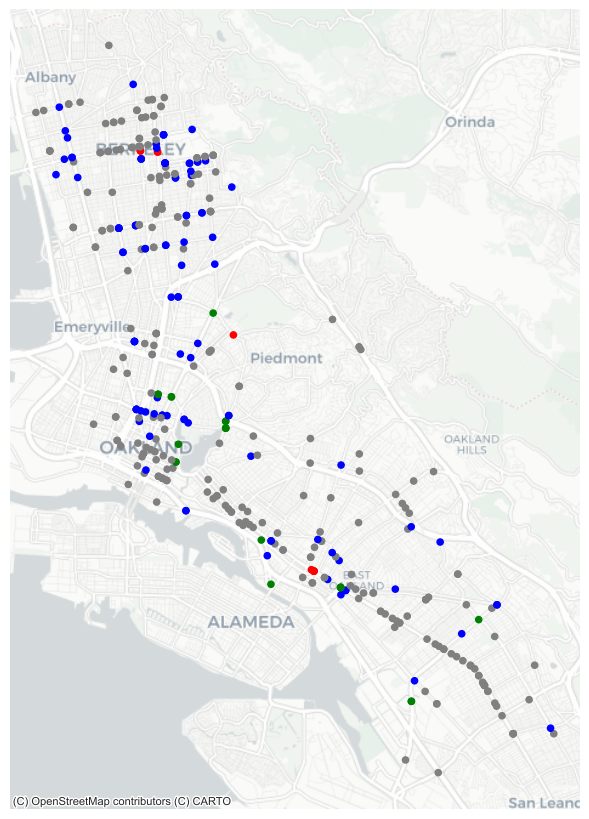

In [ ]:
from matplotlib.patches import Patch

fig = plt.figure(figsize=[12,8])
ax = fig.add_axes([0, 0, 1, 1])

# Create color column based on island_id and signal_ID
colors = []
for idx, row in gdf.iterrows():
    if row['island_id'] == 1 and row['signal_id'] == 1:
        colors.append('green')
    elif row['island_id'] == 1:
        colors.append('red')
    elif row['signal_id'] == 1:
        colors.append('blue')
    else:
        colors.append('gray')

gdf.plot(ax=ax, color=colors, markersize=20)

cx.add_basemap(ax, source=cx.providers.CartoDB.Positron)
ax.set_axis_off()

# Create legend
legend_elements = [
    Patch(facecolor='green', label='Both island_id=1 & signal_ID=1'),
    Patch(facecolor='red', label='island_id=1 only'),
    Patch(facecolor='blue', label='signal_ID=1 only'),
    Patch(facecolor='gray', label='Neither')
]
ax.legend(handles=legend_elements, loc='upper left', frameon=True)

# Select final variables for model

In [24]:
df.columns

Index(['COLLISION_SEVERITY', 'AT_FAULT', 'PARTY_SEX', 'PARTY_AGE', 'WEATHER_1',
       'PRIMARY_COLL_FACTOR', 'PARTY_NUMBER_KILLED', 'PARTY_NUMBER_INJURED',
       'road_class', 'road_class_name', 'island_id', 'volume', 'signal_id',
       'weekend', 'ped_in_xwalk', 'ped_violation_or_auto_row', 'RACE_B',
       'RACE_H', 'RACE_O', 'RACE_W', 'LIGHTING_dusk_dawn',
       'LIGHTING_no_streetlight', 'LIGHTING_streetlight'],
      dtype='object')

In [25]:
df = df[[
    'COLLISION_SEVERITY', 
    # 'AT_FAULT', # Highly correlated with 'ped_violation_or_auto_row'
    'PARTY_AGE', 
    'WEATHER_1',
    'island_id', 
    'volume', # Actually volume and road class aren't that highly correlated, so let's keep both
    'signal_id', 
    'weekend', 
    'ped_in_xwalk', 
    'ped_violation_or_auto_row',
    'road_class', 
    'PARTY_SEX', 
    'RACE_B', 
    'RACE_H',
    'RACE_O', 
    'RACE_W', 
    'LIGHTING_dusk_dawn', 
    'LIGHTING_no_streetlight',
    'LIGHTING_streetlight'
]]

# Fix data types

In [26]:
# df.dtypes

In [27]:
# cols = ['PARTY_AGE', 
#         'WEATHER_1',
#         'weekend'
#         ]

# df[cols] = df[cols].astype(int)

# df['volume'] = df['volume'].astype(float)
# df['volume'] = df['volume'].fillna(0).astype(int)
# # lets scale the volumes between 0 and 1 so they aren't such ridiculous numeric outliers
# max_value = df['volume'].max()
# df['volume'] = df['volume']/max_value

# # let's convert all the True/False into 1/0
# for col in df:
#     if df[col].dtype == bool:
#         df[col] = df[col].map(int)
# for col in df:
#     if df[col].dtype == object:
#         df[col] = df[col].map(int)

# df.dtypes

# Fix data types

In [28]:
df.dtypes

COLLISION_SEVERITY           category
PARTY_AGE                      object
WEATHER_1                      object
island_id                       int64
volume                         object
signal_id                       int64
weekend                        object
ped_in_xwalk                  float64
ped_violation_or_auto_row     float64
road_class                     object
PARTY_SEX                      object
RACE_B                           bool
RACE_H                           bool
RACE_O                           bool
RACE_W                           bool
LIGHTING_dusk_dawn               bool
LIGHTING_no_streetlight          bool
LIGHTING_streetlight             bool
dtype: object

In [29]:
cols = ['PARTY_AGE', 
        'WEATHER_1',
        'weekend',
        'road_class',
        'PARTY_SEX'
        ]

df[cols] = df[cols].astype(int)

df['volume'] = df['volume'].astype(float)
df['volume'] = df['volume'].fillna(0).astype(int)
# lets scale the volumes between 0 and 1 so they aren't such ridiculous numeric outliers
max_value = df['volume'].max()
print("max volume: ", max_value)
df['volume'] = df['volume']/max_value

df.drop(df[df['PARTY_AGE'] > 120].index, inplace=True)
max_value = df['PARTY_AGE'].max()
print("max age: ", max_value)
df['PARTY_AGE'] = df['PARTY_AGE']/max_value

# let's convert all the True/False into 1/0
for col in df:
    if df[col].dtype == bool:
        df[col] = df[col].map(int)
for col in df:
    if df[col].dtype == object:
        df[col] = df[col].map(int)

df.dtypes

max volume:  55757349
max age:  90


COLLISION_SEVERITY           category
PARTY_AGE                     float64
WEATHER_1                       int64
island_id                       int64
volume                        float64
signal_id                       int64
weekend                         int64
ped_in_xwalk                  float64
ped_violation_or_auto_row     float64
road_class                      int64
PARTY_SEX                       int64
RACE_B                          int64
RACE_H                          int64
RACE_O                          int64
RACE_W                          int64
LIGHTING_dusk_dawn              int64
LIGHTING_no_streetlight         int64
LIGHTING_streetlight            int64
dtype: object

# Correlation matrices

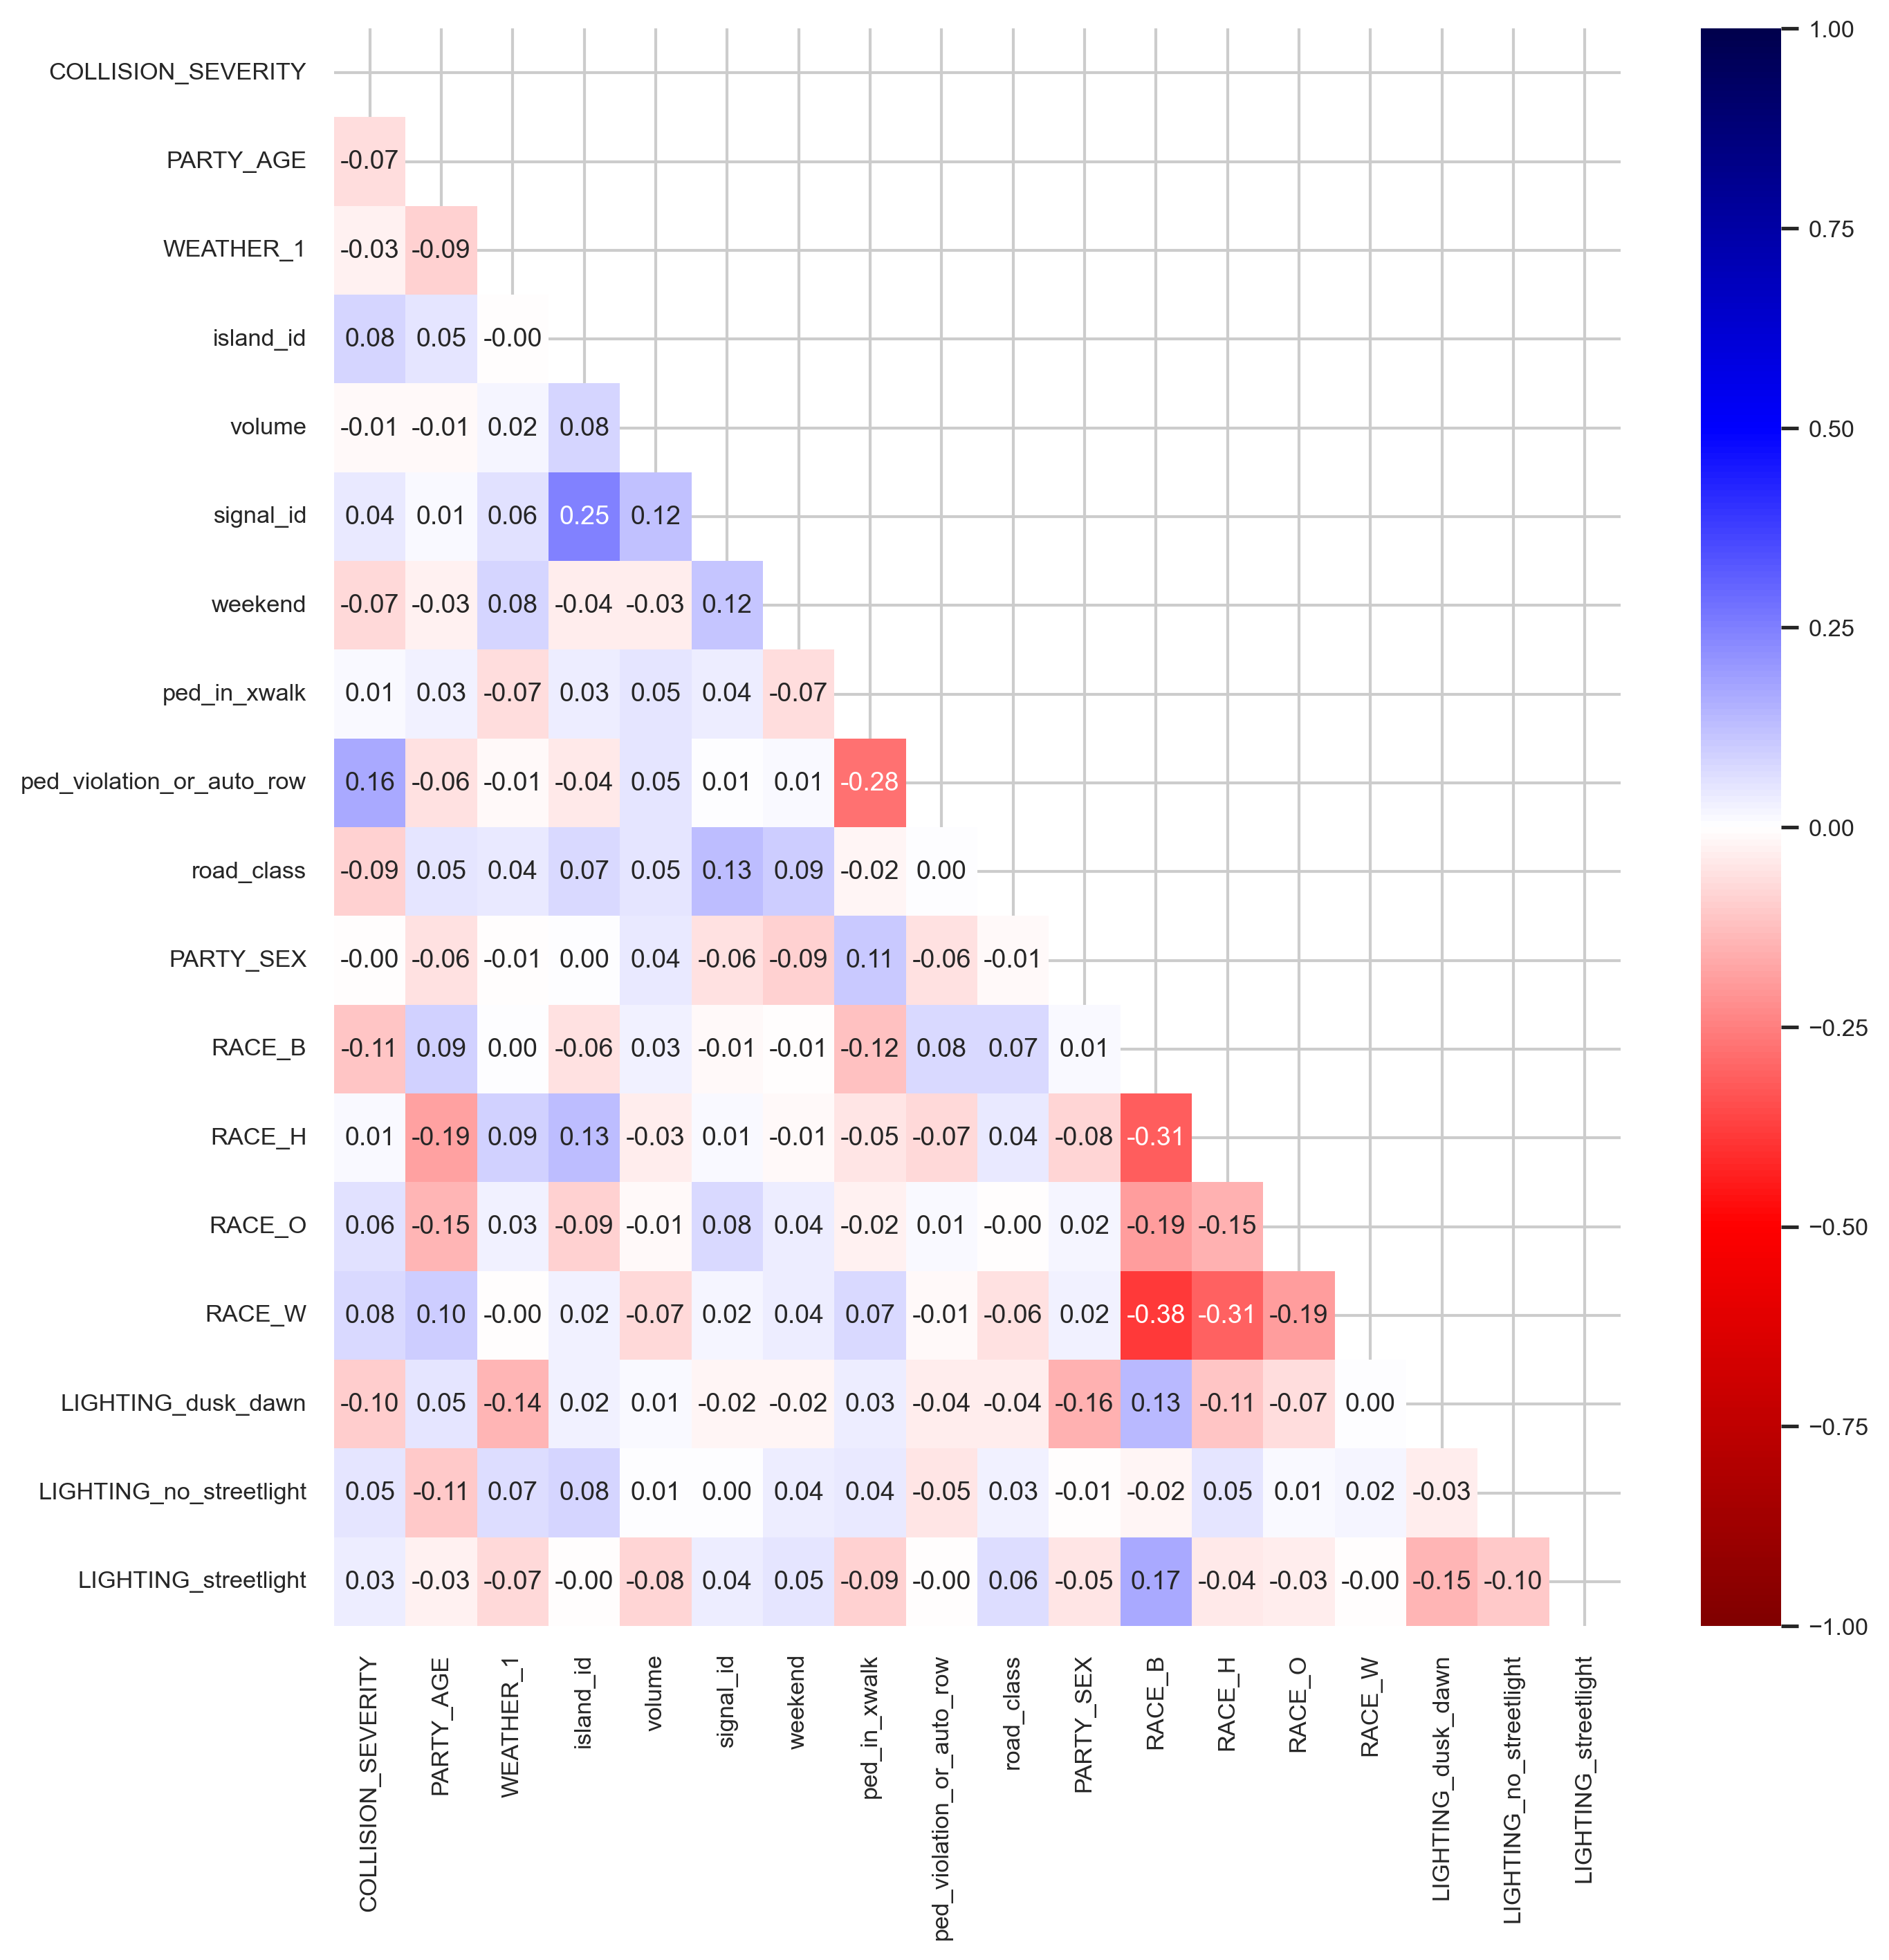

In [30]:
#Create heatmap of correlations among the variables
plt.figure(figsize=(10, 10), dpi=300) # Width, Height in inches
sns.set(context='notebook', style='whitegrid', font_scale=0.75)
upper = np.triu(df.corr())  # Here, we are looking at the upper triangle. Optionally, you can just look at the lower triangle. 
sns.heatmap(df.corr(), cmap="seismic_r", annot=True, vmin=-1, vmax=1, mask=upper, fmt=".2f");
plt.savefig('heatmap.png')

In [31]:
print(df['COLLISION_SEVERITY'].value_counts(normalize = True, dropna = False))
print(df['COLLISION_SEVERITY'].value_counts(normalize = False, dropna = False))

COLLISION_SEVERITY
1    0.434343
2    0.421717
3    0.121212
4    0.022727
Name: proportion, dtype: float64
COLLISION_SEVERITY
1    172
2    167
3     48
4      9
Name: count, dtype: int64


In [32]:
display(pd.crosstab(df['COLLISION_SEVERITY'], df['island_id']))
display(pd.crosstab(df['COLLISION_SEVERITY'], df['island_id'], normalize='columns'))

island_id,0,1
COLLISION_SEVERITY,,
1,159,13
2,157,10
3,41,7
4,7,2


island_id,0,1
COLLISION_SEVERITY,,
1,0.436813,0.40625
2,0.431319,0.31250
3,0.112637,0.21875
4,0.019231,0.06250


In [33]:
display(pd.crosstab(df['COLLISION_SEVERITY'], df['signal_id']))
display(pd.crosstab(df['COLLISION_SEVERITY'], df['signal_id'], normalize = 'columns'))

signal_id,0,1
COLLISION_SEVERITY,,
1,121,51
2,108,59
3,32,16
4,6,3


signal_id,0,1
COLLISION_SEVERITY,,
1,0.453184,0.395349
2,0.404494,0.457364
3,0.119850,0.124031
4,0.022472,0.023256


# Run model

In [34]:
# Define independent variables (all columns except the target)
independent_vars = df.columns.difference(['COLLISION_SEVERITY'])

independent_vars

Index(['LIGHTING_dusk_dawn', 'LIGHTING_no_streetlight', 'LIGHTING_streetlight',
       'PARTY_AGE', 'PARTY_SEX', 'RACE_B', 'RACE_H', 'RACE_O', 'RACE_W',
       'WEATHER_1', 'island_id', 'ped_in_xwalk', 'ped_violation_or_auto_row',
       'road_class', 'signal_id', 'volume', 'weekend'],
      dtype='object')

In [35]:
df.head()
df['road_class'].value_counts()

road_class
0    209
1    187
Name: count, dtype: int64

In [36]:
# Specify and calibrate the Ordered Logit Model
model = OrderedModel(
    endog=df["COLLISION_SEVERITY"],
    exog=df[independent_vars],
    distr="logit"
)

# I tried some different model methods. I think we may have too many un-useful independent variables
# result = model.fit(method="cg")
# result = model.fit(method="nm")
result = model.fit(method="bfgs")
print(result.summary())

Optimization terminated successfully.
         Current function value: 1.026282
         Iterations: 92
         Function evaluations: 94
         Gradient evaluations: 94
                             OrderedModel Results                             
Dep. Variable:     COLLISION_SEVERITY   Log-Likelihood:                -406.41
Model:                   OrderedModel   AIC:                             852.8
Method:            Maximum Likelihood   BIC:                             932.4
Date:                Sat, 02 May 2026                                         
Time:                        14:46:51                                         
No. Observations:                 396                                         
Df Residuals:                     376                                         
Df Model:                          17                                         
                                coef    std err          z      P>|z|      [0.025      0.975]
-----------------------

In [37]:
print("Psuedo r^2 value:", result.prsquared)  # Access McFadden's Pseudo R2

Psuedo r^2 value: 0.03916450437571284


In [38]:
df['COLLISION_SEVERITY'].value_counts()

COLLISION_SEVERITY
1    172
2    167
3     48
4      9
Name: count, dtype: int64

In [39]:
# I don't know how to do the interaction of variables using the above method.
# Trying a diff method.
import statsmodels.formula.api as smf

# df['COLLISION_SEVERITY'] = df['COLLISION_SEVERITY'].astype('category').cat.codes
# print(df['COLLISION_SEVERITY'].value_counts())

# One of the issues of using smf.logit (below) is that it can only an independent variable of 1/0
df.loc[(df['COLLISION_SEVERITY']==1)|(df['COLLISION_SEVERITY']==2), 'test_collision_serverity'] = 0
df.loc[(df['COLLISION_SEVERITY']==3)|(df['COLLISION_SEVERITY']==4), 'test_collision_serverity'] = 1 # B - Crossing in Crosswalk at Intersection

# Plain model without interactions
model = smf.logit(formula='test_collision_serverity ~ PARTY_AGE + WEATHER_1 + island_id + volume + \
                        signal_id + weekend + ped_violation_or_auto_row + \
                        road_class + PARTY_SEX + RACE_B + RACE_H + RACE_O + RACE_W + \
                        LIGHTING_dusk_dawn + LIGHTING_no_streetlight + LIGHTING_streetlight', 
                data=df)

# # Model with interactions
# model = smf.logit(formula='test_collision_serverity ~ PARTY_AGE + WEATHER_1 + island_id:signal_id + volume + \
#                         weekend + ped_in_xwalk + ped_violation_or_auto_row + \
#                         road_class + PARTY_SEX + RACE_B + RACE_H + RACE_O + RACE_W + \
#                         LIGHTING_dusk_dawn + LIGHTING_no_streetlight + LIGHTING_streetlight', 
#                 data=df
#                 )

result = model.fit()
print(result.summary())

Optimization terminated successfully.
         Current function value: 0.369844
         Iterations 7
                              Logit Regression Results                              
Dep. Variable:     test_collision_serverity   No. Observations:                  396
Model:                                Logit   Df Residuals:                      379
Method:                                 MLE   Df Model:                           16
Date:                      Sat, 02 May 2026   Pseudo R-squ.:                  0.1024
Time:                              14:46:52   Log-Likelihood:                -146.46
converged:                             True   LL-Null:                       -163.17
Covariance Type:                  nonrobust   LLR p-value:                  0.006483
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept                    -

In [40]:
df.columns

Index(['COLLISION_SEVERITY', 'PARTY_AGE', 'WEATHER_1', 'island_id', 'volume',
       'signal_id', 'weekend', 'ped_in_xwalk', 'ped_violation_or_auto_row',
       'road_class', 'PARTY_SEX', 'RACE_B', 'RACE_H', 'RACE_O', 'RACE_W',
       'LIGHTING_dusk_dawn', 'LIGHTING_no_streetlight', 'LIGHTING_streetlight',
       'test_collision_serverity'],
      dtype='object')

In [41]:
# Compute and display Odds Ratios
odds_ratios = np.exp(result.params)
print("\nOdds Ratios:\n", odds_ratios)

# Predict probabilities for each severity level
predicted_probs = result.predict()

# Convert predictions to a DataFrame
predicted_probs_df = pd.DataFrame(predicted_probs)

# Determine the most likely severity level for each observation
df["Predicted_Severity"] = predicted_probs_df.idxmax(axis=1)

# Display performance metrics with a confusion matrix (objective results only)
confusion_matrix = pd.crosstab(df["COLLISION_SEVERITY"], df["Predicted_Severity"],
                               rownames=['Actual'], colnames=['Predicted'])
print("\nConfusion Matrix:\n", confusion_matrix)



Odds Ratios:
 Intercept                    0.126276
PARTY_AGE                    2.321083
WEATHER_1                    0.711842
island_id                    2.791834
volume                       0.132113
signal_id                    0.912318
weekend                      0.550932
ped_violation_or_auto_row    3.842325
road_class                   0.479939
PARTY_SEX                    0.855031
RACE_B                       1.067360
RACE_H                       2.709085
RACE_O                       1.325507
RACE_W                       1.209043
LIGHTING_dusk_dawn           0.422635
LIGHTING_no_streetlight      2.788258
LIGHTING_streetlight         1.789088
dtype: float64

Confusion Matrix:
 Predicted  0.0
Actual        
1          131
2           76
3           20
4            7


In [42]:
# Plain model without interactions
for var in independent_vars: 
        model = smf.logit(formula=f'test_collision_serverity ~ {var}', 
                        data=df)

        result = model.fit()
        print(result.summary())

Optimization terminated successfully.
         Current function value: 0.410169
         Iterations 7
                              Logit Regression Results                              
Dep. Variable:     test_collision_serverity   No. Observations:                  396
Model:                                Logit   Df Residuals:                      394
Method:                                 MLE   Df Model:                            1
Date:                      Sat, 02 May 2026   Pseudo R-squ.:                0.004568
Time:                              14:46:52   Log-Likelihood:                -162.43
converged:                             True   LL-Null:                       -163.17
Covariance Type:                  nonrobust   LLR p-value:                    0.2221
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept             -1.7492      0.145    

(array([ 7., 22., 90., 46., 46., 53., 53., 45., 25.,  9.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <BarContainer object of 10 artists>)

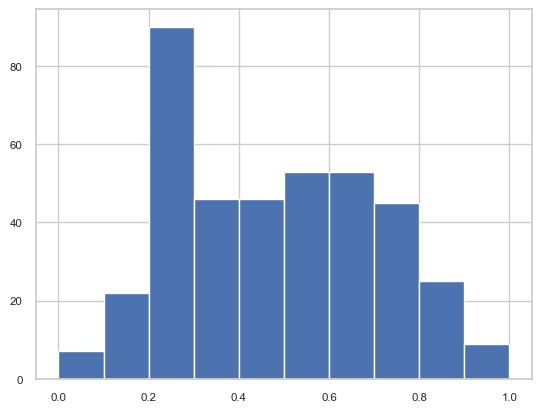

In [43]:
plt.hist(df['PARTY_AGE'])

In [44]:
df['PARTY_AGE'].value_counts()

PARTY_AGE
0.255556    13
0.211111    12
0.222222    12
0.233333    11
0.244444    10
            ..
0.155556     1
1.000000     1
0.577778     1
0.133333     1
0.077778     1
Name: count, Length: 78, dtype: int64